In [ ]:
import kagglehub
import pandas as pd
import os
from sklearn.model_selection import train_test_split


In [ ]:
path = kagglehub.dataset_download("davidgauthier/glassdoor-job-reviews")
# Assuming 'path' variable holds the directory where the dataset was downloaded
print(os.listdir(path))

100%|██████████| 83.9M/83.9M [00:00<00:00, 93.8MB/s]

Extracting files...


In [ ]:

file_path = os.path.join(path, 'glassdoor_reviews.csv')
df = pd.read_csv(file_path)
print(df.head())

In [ ]:
df.info()

synthetic data

In [ ]:
file_path = '/content/drive/MyDrive/hr_performance_reviews_700_no_special_chars.csv'
synthetic_df = pd.read_csv(file_path)
display(synthetic_df.head())

In [ ]:
print(synthetic_df["text"].str.len().describe())

drob the na

In [ ]:
df = df.dropna(subset=["pros", "cons", "overall_rating"])

In [ ]:
df.info()

separating the cons and pros from the ds

In [ ]:
pros_df=pd.DataFrame({"text":df['pros'].values, "rating":df['overall_rating'].values,"source":"pros"})
pros_df.head()

In [ ]:
cons_df=pd.DataFrame({"text":df['cons'].values, "rating":df['overall_rating'].values,"source":"cons"})
cons_df.head()

In [ ]:
conc_df=pd.concat([pros_df,cons_df],ignore_index=True)
conc_df.head()


In [ ]:
conc_df.info()

make the lable for the reviews instade of just number rate

In [ ]:
def assign_label(row):
    if row["source"] == "pros":
        # Pros are always positive regardless of rating
        return "joy"

    else:  # cons
        # The rating tells you HOW negative the cons are
        if row["rating"] == 1:
            return "anger"      # 1-star: strong negative, frustrated tone
        elif row["rating"] == 2:
            return "sadness"    # 2-star: disappointed tone
        elif row["rating"] == 3:
            return "neutral"    # 3-star: mild complaint, balanced
        else:
            return "neutral"    # 4-5 star cons are minor nitpicks

conc_df["label"] = conc_df.apply(assign_label, axis=1)

# Drop the helper columns, keep only what the model needs
text_lable_df = conc_df[["text", "label"]]

In [ ]:
conc_df.head()

In [ ]:
text_lable_df = conc_df[["text", "label"]]
text_lable_df.head()

In [ ]:
print(text_lable_df['label'].unique())

In [ ]:
text_lable_df.info()

In [ ]:
print(text_lable_df["text"].str.len().describe())

In [ ]:
max_text_length = text_lable_df['text'].str.len().max()
longest_text_row = text_lable_df[text_lable_df['text'].str.len() == max_text_length]

print(longest_text_row.to_string())

In [ ]:
import re

def clean_text(text):
    if isinstance(text, str):
        # Remove non-alphanumeric characters (keep letters, numbers, and spaces)
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        # Replace multiple spaces with a single space
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    return text

text_lable_df['text'] = text_lable_df['text'].apply(clean_text)
print("Text column after removing special characters:")
print(text_lable_df.head())

In [ ]:
filtered_text_df = text_lable_df[text_lable_df['text'].str.len() <= 200]

print(f"Original DataFrame size: {len(text_lable_df)}")
print(f"Filtered DataFrame size: {len(filtered_text_df)}")
print("\nHead of the new filtered DataFrame:")
display(filtered_text_df.head())
print("\nInfo of the new filtered DataFrame:")
filtered_text_df.info()

In [ ]:
print(filtered_text_df["text"].str.len().describe())

In [ ]:
TARGET_PER_CLASS = 800

sampled_df = (
    filtered_text_df
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(n=TARGET_PER_CLASS, random_state=42))
    .reset_index(drop=True)
)

print(sampled_df["label"].value_counts())


In [ ]:
print(sampled_df["text"].str.len().describe())

In [ ]:
sampled_df.info()

In [ ]:
print(sampled_df["text"].str.len().describe())

before concat

In [ ]:
#synth_org_df=pd.concat([sampled_df,synthetic_df],ignore_index=True)
#synth_org_df.head()

In [ ]:
#print(synth_org_df["text"].str.len().describe())

shuffle the rows

In [ ]:
#synth_org_df = synth_org_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
#print(synth_org_df["label"].value_counts())

In [ ]:
#synth_org_df.to_csv("hr_emotion_dataset_lasttttt.csv", index=False)
#print(f"Final dataset: {len(synth_org_df)} rows")

**data set is now ready**

In [ ]:
#print(synth_org_df["text"].str.len().describe())

new df

In [ ]:
import pandas as pd
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
augmented_df=pd.read_csv("/content/drive/MyDrive/fully_cleaned_hr_emotion_dataset.csv")



In [ ]:
print(augmented_df["text"].str.len().describe())

count    4882.000000
mean       73.827120
std        37.989944
min        14.000000
25%        44.000000
50%        67.000000
75%        93.000000
max       200.000000
Name: text, dtype: float64


**data set is ready**

In [ ]:
# Sanity check before proceeding
#print(synth_org_df.shape)
#print(synth_org_df["label"].value_counts())
#print(synth_org_df.dtypes)
#print(synth_org_df.isnull().sum())
#rint(synth_org_df.head(3))

encode the lable

In [ ]:
label2id = {
    "anger":    0,
    "disgust":  1,
    "fear":     2,
    "joy":      3,
    "neutral":  4,
    "sadness":  5,
    "surprise": 6
}
id2label = {v: k for k, v in label2id.items()}

#synth_org_df["label"] = synth_org_df["label"].map(label2id)

# Verify — must print 0
#print("Unmapped labels:", synth_org_df["label"].isna().sum())

In [ ]:
augmented_df["label"] = augmented_df["label"].map(label2id)


In [ ]:
#synth_org_df.head()

In [ ]:
import re

def preprocess_hr(text):
    text = str(text).strip()
    text = re.sub(r"\b\d{1,2}/\d{1,2}/\d{2,4}\b", "[DATE]", text)
    text = re.sub(r"\b[A-Z][a-z]+ [A-Z][a-z]+\b", "[EMPLOYEE]", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

augmented_df["text"] = augmented_df["text"].apply(preprocess_hr)

In [ ]:
print("Unmapped labels:", augmented_df["label"].isna().sum())

Unmapped labels: 0


In [ ]:
augmented_df = augmented_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(augmented_df["label"].value_counts())

label
5    1000
0     800
3     799
4     799
6     497
1     496
2     492
Name: count, dtype: int64


Train/Validation Split

# **re run**

In [ ]:
train_df, val_df = train_test_split(
    augmented_df,
    test_size=0.2,
    stratify=augmented_df["label"],  # Keeps class ratio equal in both splits
    random_state=42
)

print("Train size:", len(train_df))
print("Val size:  ", len(val_df))
print(train_df["label"].value_counts())

Train size: 3906
Val size:   977
label
5    800
0    640
3    639
4    639
6    397
1    397
2    394
Name: count, dtype: int64


Install & Load Tokenizer

In [ ]:
!pip install transformers datasets torch accelerate evaluate scikit-learn -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.3 MB/s eta 0:00:00


In [ ]:
#!pip install transformers datasets torch accelerate evaluate scikit-learn -q

from transformers import AutoTokenizer
from datasets import Dataset

MODEL_NAME = "j-hartmann/emotion-english-distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = Dataset.from_pandas(train_df[["text", "label"]].reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df[["text", "label"]].reset_index(drop=True))

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset   = val_dataset.map(tokenize, batched=True)

print("Tokenization done ✓")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Map:   0%|          | 0/3906 [00:00<?, ? examples/s]

Map:   0%|          | 0/977 [00:00<?, ? examples/s]

Tokenization done ✓


Compute Class Weights

In [ ]:
import numpy as np
import torch
from sklearn.utils.class_weight import compute_class_weight

classes = np.array(sorted(augmented_df["label"].unique()))
weights = compute_class_weight("balanced", classes=classes, y=augmented_df["label"])
class_weights = torch.tensor(weights, dtype=torch.float)

print("Class weights:")
for i, w in enumerate(class_weights):
    print(f"  {id2label[i]}: {w:.4f}")

Class weights:
  anger: 0.8720
  disgust: 1.4064
  fear: 1.4178
  joy: 0.8731
  neutral: 0.8731
  sadness: 0.6976
  surprise: 1.4036


 Load Model + Define Weighted Trainer

In [ ]:
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, Trainer

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=7,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Metrics

In [ ]:
import evaluate

metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return metric.compute(predictions=preds, references=labels, average="weighted")

Training Arguments

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./hr-sentiment-model",
    eval_strategy="epoch",           # ← changed from evaluation_strategy
    save_strategy="epoch",
    learning_rate=1e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    logging_steps=20,
    save_total_limit=2,
)

print("Training args ready ✓")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training args ready ✓


train

In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,      # ← changed from tokenizer
    compute_metrics=compute_metrics,
)

print("Trainer ready ✓")
trainer.train()


Trainer ready ✓


Epoch,Training Loss,Validation Loss,F1
1,0.629353,0.626679,0.674016
2,0.482730,0.542529,0.709718
3,0.499397,0.531058,0.725519
4,0.369989,0.537425,0.730173
5,0.371624,0.543972,0.721687


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1225, training_loss=0.5193975055461028, metrics={'train_runtime': 142.4635, 'train_samples_per_second': 137.088, 'train_steps_per_second': 8.599, 'total_flos': 646829745246720.0, 'train_loss': 0.5193975055461028, 'epoch': 5.0})

valuate Per Class

In [ ]:
from sklearn.metrics import classification_report

preds_output = trainer.predict(val_dataset)
preds  = preds_output.predictions.argmax(-1)
labels = preds_output.label_ids

print(classification_report(
    labels, preds,
    target_names=[id2label[i] for i in range(7)]
))

              precision    recall  f1-score   support

       anger       0.53      0.51      0.52       160
     disgust       0.96      0.99      0.98        99
        fear       0.95      1.00      0.98        98
         joy       0.88      0.90      0.89       160
     neutral       0.56      0.74      0.64       160
     sadness       0.57      0.41      0.48       200
    surprise       0.99      1.00      1.00       100

    accuracy                           0.74       977
   macro avg       0.78      0.79      0.78       977
weighted avg       0.73      0.74      0.73       977



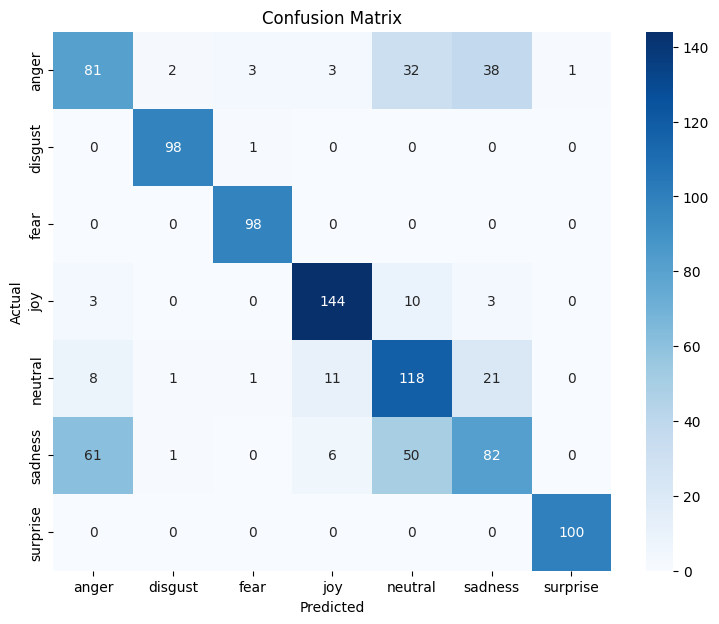

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[id2label[i] for i in range(7)],
    yticklabels=[id2label[i] for i in range(7)],
    cmap="Blues"
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.show()

there is alwais confusion between the sadness, anger, neutral

# ** test**

In [ ]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

# Test it
text = "Noha was late today and ditn answer my emails"
result = classifier(text)

print(f"Label:      {result[0]['label']}")
print(f"Confidence: {result[0]['score']:.2%}")

Label:      sadness
Confidence: 51.62%


To save the trained model, you can use the `trainer.save_model()` method. This will save the model's weights and configuration, as well as the tokenizer, to the specified output directory.

In [ ]:


# Save the final model and tokenizer
trainer.save_model("./hr-sentiment-model")
tokenizer.save_pretrained("./hr-sentiment-model")
print("Model and tokenizer saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved successfully.


To load the saved model and tokenizer, you can use the `AutoTokenizer.from_pretrained()` and `AutoModelForSequenceClassification.from_pretrained()` methods, pointing them to your saved directory.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Load the tokenizer and model from the saved directory
loaded_tokenizer = AutoTokenizer.from_pretrained("./hr-sentiment-model")
loaded_model = AutoModelForSequenceClassification.from_pretrained("./hr-sentiment-model")

# Create a pipeline with the loaded model and tokenizer
loaded_classifier = pipeline(
    "text-classification",
    model=loaded_model,
    tokenizer=loaded_tokenizer,
    device=0 if torch.cuda.is_available() else -1 # Use GPU if available
)

print("Model and tokenizer loaded successfully.")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Model and tokenizer loaded successfully.


First, let's save the model to your Google Drive so it persists across sessions. Make sure your Google Drive is mounted (`/content/drive` needs to be accessible).

In [ ]:
# This is the previous cell where you saved the model.
# You can modify it to save to Google Drive.

# Define a path in your Google Drive to save the model
DRIVE_MODEL_PATH = "/content/drive/MyDrive/Colab_Notebooks/tokenizer/sentment-hr"

# Make sure Google Drive is mounted (if not already)
from google.colab import drive
drive.mount('/content/drive')

# Save the final model and tokenizer to Google Drive
trainer.save_model(DRIVE_MODEL_PATH)
tokenizer.save_pretrained(DRIVE_MODEL_PATH)
print(f"Model and tokenizer saved successfully to {DRIVE_MODEL_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved successfully to /content/drive/MyDrive/Colab_Notebooks/tokenizer/sentment-hr


Now you can use this `loaded_classifier` just like you used the `classifier` before to make predictions on new text.

In [ ]:
# Test the loaded classifier with an example text
text_to_test = "I am very happy with my new job and the team."
result = loaded_classifier(text_to_test)

print(f"Text: {text_to_test}")
print(f"Predicted Label: {result[0]['label']}")
print(f"Confidence: {result[0]['score']:.2%}")


Text: I am very happy with my new job and the team.
Predicted Label: joy
Confidence: 99.65%


to re run  1 run the map, then the below

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
tokenizer = AutoTokenizer.from_pretrained("j-hartmann/emotion-english-distilroberta-base")
model = AutoModelForSequenceClassification.from_pretrained("./hr-sentiment-model/checkpoint-1225")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### To load the model after a session reset:

If you restart your Colab session, you'll need to run the following cells in order:

1.  **Mount Google Drive** (if not already mounted).
2.  **Load the tokenizer and model** from the specified Google Drive path.
3.  **Re-create the `pipeline`** for inference.
4.  Then you can **test** it.


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# Define the path where your model is saved on Google Drive
DRIVE_MODEL_PATH = "/content/drive/MyDrive/Colab_Notebooks/tokenizer/sentment-hr"

# 2. Load the tokenizer and model from Google Drive
loaded_tokenizer = AutoTokenizer.from_pretrained(DRIVE_MODEL_PATH)
loaded_model = AutoModelForSequenceClassification.from_pretrained(DRIVE_MODEL_PATH)

# 3. Create a pipeline with the loaded model and tokenizer
loaded_classifier = pipeline(
    "text-classification",
    model=loaded_model,
    tokenizer=loaded_tokenizer,
    device=0 if torch.cuda.is_available() else -1 # Use GPU if available
)

print("Model and tokenizer loaded successfully from Google Drive.")




ValueError: mount failed

# test

In [ ]:
text_to_test = ""
result = loaded_classifier(text_to_test)

#print(f"Text: {text_to_test}")
print(f"Predicted Label: {result[0]['label']}")
print(f"Confidence: {result[0]['score']:.2%}")

Predicted Label: neutral
Confidence: 77.10%


Map:   0%|          | 0/977 [00:00<?, ? examples/s]

Validation dataset prepared.



ValueError: text input must be of type `str` (single example), `list[str]` (batch or single pretokenized example) or `list[list[str]]` (batch of pretokenized examples) or `list[tuple[list[str], list[str]]]` (batch of pretokenized sequence pairs).